In [2]:
import pandas as pd
import joblib

calibrated_model = joblib.load('../model/xgb_model.pkl')
xgb_model = joblib.load('../model/xgb_model_raw.pkl')
X_test = joblib.load('../model/X_test.pkl')
X_test_scaled = joblib.load('../model/X_test_scaled.pkl')
y_test = joblib.load('../model/y_test.pkl')
X_train = joblib.load('../model/X_train.pkl')

In [3]:
results = X_test.copy()
results['true_label'] = y_test.values
results['predicted_proba'] = calibrated_model.predict_proba(X_test_scaled)[:,1]
results['predicted_label'] = (results['predicted_proba'] >= 0.5).astype(int)
results['confidence'] = results['predicted_proba'].apply(lambda p: max(p, 1-p))

high_conf = results[results['confidence'] >= 0.85]
failures = high_conf[high_conf['predicted_label'] != high_conf['true_label']]

high_conf_error_rate = len(failures) / len(high_conf)
print(f"High-confidence error rate: {high_conf_error_rate:.2%}")

High-confidence error rate: 3.10%


In [4]:
correct_high_conf = high_conf[high_conf['predicted_label'] == high_conf['true_label']]

for col in ['age','DebtRatio','MonthlyIncome','RevolvingUtilizationOfUnsecuredLines']:
    print(col, "| Failures mean:", failures[col].mean(), "| Correct mean:", correct_high_conf[col].mean())

age | Failures mean: 47.675970873786405 | Correct mean: 53.51330282345641
DebtRatio | Failures mean: 469.37857915107764 | Correct mean: 367.62937314989307
MonthlyIncome | Failures mean: 5919.462209302325 | Correct mean: 6964.0496453900705
RevolvingUtilizationOfUnsecuredLines | Failures mean: 0.482446526776699 | Correct mean: 5.427138539923364


c:\Users\Devanshi\auditai\auditai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


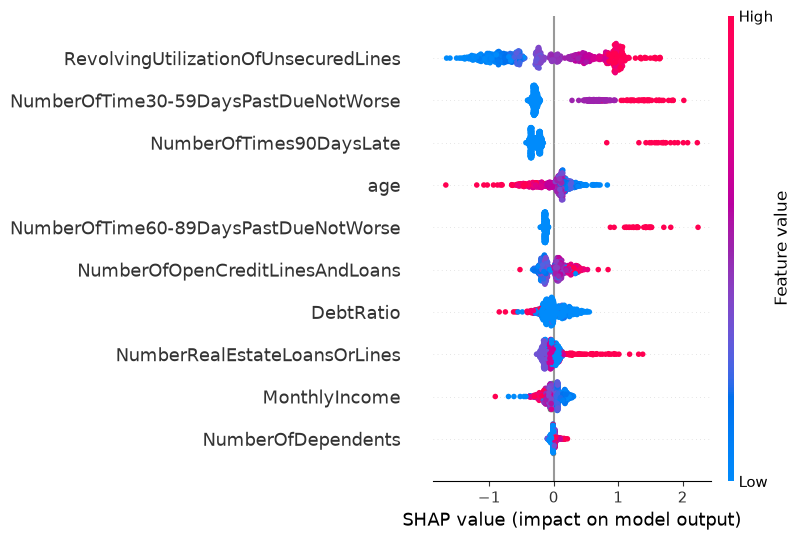

In [5]:
import shap

explainer = shap.TreeExplainer(xgb_model)
failure_positions = [X_test.index.get_loc(i) for i in failures.index]
shap_values_failures = explainer(X_test_scaled[failure_positions])
shap.summary_plot(shap_values_failures, X_test.loc[failures.index])

In [6]:
df_agegroup = pd.read_csv('../data/cs-training-with-agegroup.csv', index_col=0)['age_group']
failures_age = failures.join(df_agegroup)
high_conf_age = high_conf.join(df_agegroup)

print(failures_age['age_group'].value_counts(normalize=True))
print(high_conf_age['age_group'].value_counts(normalize=True))

age_group
40-60    0.509709
25-40    0.286408
60+      0.172330
<25      0.031553
Name: proportion, dtype: float64
age_group
40-60    0.462793
60+      0.326518
25-40    0.193325
<25      0.017363
Name: proportion, dtype: float64


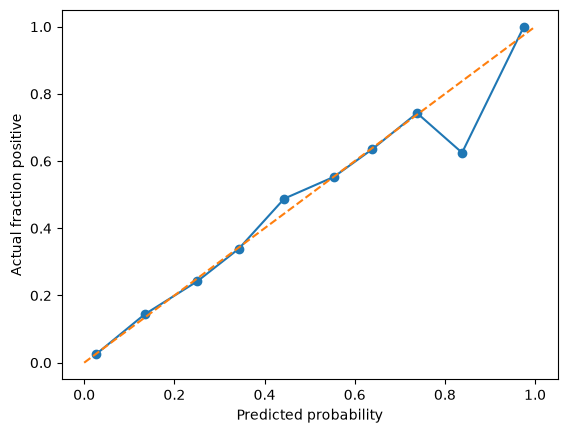

ECE: 0.0029


In [7]:
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, results['predicted_proba'], n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted probability'); plt.ylabel('Actual fraction positive')
plt.savefig('../outputs/calibration_curve.png')
plt.show()

def expected_calibration_error(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0
    for i in range(n_bins):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_proba[mask].mean()
            ece += (mask.sum()/len(y_proba)) * abs(bin_acc - bin_conf)
    return ece

ece = expected_calibration_error(y_test.values, results['predicted_proba'].values)
print(f"ECE: {ece:.4f}")

In [8]:
COST_FALSE_POSITIVE = 5000
COST_FALSE_NEGATIVE = 800

fp = ((results['predicted_label']==0) & (results['true_label']==1)).sum()
fn = ((results['predicted_label']==1) & (results['true_label']==0)).sum()
total_cost = fp*COST_FALSE_POSITIVE + fn*COST_FALSE_NEGATIVE

failure_fp = ((failures['predicted_label']==0) & (failures['true_label']==1)).sum()
failure_fn = ((failures['predicted_label']==1) & (failures['true_label']==0)).sum()
failure_cost = failure_fp*COST_FALSE_POSITIVE + failure_fn*COST_FALSE_NEGATIVE

print(f"Total cost: {total_cost} | High-confidence failure cost: {failure_cost} ({failure_cost/total_cost:.1%})")

Total cost: 8493600 | High-confidence failure cost: 4115800 (48.5%)


In [9]:
thresholds = np.arange(0.1, 0.9, 0.01)
costs = []
for t in thresholds:
    pred = (results['predicted_proba'] >= t).astype(int)
    fp_t = ((pred==1) & (results['true_label']==0)).sum()
    fn_t = ((pred==0) & (results['true_label']==1)).sum()
    costs.append(fp_t*COST_FALSE_POSITIVE + fn_t*COST_FALSE_NEGATIVE)

best_threshold = thresholds[np.argmin(costs)]
print(f"Cost-optimal threshold: {best_threshold}")

Cost-optimal threshold: 0.8599999999999995


In [10]:
def categorize_failure(row, debt_ratio_p99):
    if 0.85 <= row['confidence'] < 0.90:
        return 'Boundary case'
    if row['age'] < 25 or row['age'] > 65:
        return 'Demographic subgroup risk'
    if row['DebtRatio'] > debt_ratio_p99:
        return 'Outlier / distribution shift'
    return 'Unexplained high-confidence error'

debt_ratio_p99 = X_train['DebtRatio'].quantile(0.99)
failures = failures.copy()
failures['failure_category'] = failures.apply(lambda r: categorize_failure(r, debt_ratio_p99), axis=1)
failures['case_id'] = failures.index

failures.to_csv('../outputs/failure_taxonomy.csv', index=False)

In [11]:
export = results.join(pd.read_csv('../data/cs-training-with-agegroup.csv', index_col=0)['age_group'])
export['confidence_band'] = pd.cut(export['confidence'], bins=[0.5,0.6,0.7,0.8,0.85,0.9,0.95,1.0])
export.to_csv('../outputs/powerbi_export.csv', index=True)
failures.to_csv('../outputs/powerbi_failures.csv', index=False)  # already saved as failure_taxonomy.csv